**Task 1: Dataset Understanding**

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


**# Load the uploaded DDoS dataset**



In [40]:
file_path = "/content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
df = pd.read_csv(file_path)

**# Clean column names (The CICIDS2017 dataset has  whitespaces)**

In [41]:
df.columns = df.columns.str.strip()

**# Explore Dataset Dimensions and Class Balance**

In [42]:
print(f"Dataset Shape: {df.shape}")
print("\nTarget Class Distribution:")
print(df['Label'].value_counts())

Dataset Shape: (225745, 85)

Target Class Distribution:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64



**# Inspect Feature Data Types and Initial data Summary**

In [43]:
print("\n--- Dataset Summary Info ---")
print(df.info())


--- Dataset Summary Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 85 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Flow ID                      225745 non-null  object 
 1   Source IP                    225745 non-null  object 
 2   Source Port                  225745 non-null  int64  
 3   Destination IP               225745 non-null  object 
 4   Destination Port             225745 non-null  int64  
 5   Protocol                     225745 non-null  int64  
 6   Timestamp                    225745 non-null  object 
 7   Flow Duration                225745 non-null  int64  
 8   Total Fwd Packets            225745 non-null  int64  
 9   Total Backward Packets       225745 non-null  int64  
 10  Total Length of Fwd Packets  225745 non-null  int64  
 11  Total Length of Bwd Packets  225745 non-null  int64  
 12  Fwd Packet Length Max       

**2. Data Preprocessing**

In [44]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

**# Handle Missing Values and Anomalies (Infinity values from division-by-zero)**

In [45]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

**# Drop non-generalizable network identifiers (if present)**

In [46]:
drop_cols = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True, errors='ignore')

**# Separate features and targets**

In [47]:
X = df.drop(columns=['Label'])
y = df['Label']

**# Feature Encoding (Label encoding for binary target: BENIGN = 0, DDoS = 1)**

In [48]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

**# Split Dataset into Train and Test sets (Stratified to maintain class balance)**

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

**# Feature Scaling/Normalization (Crucial for KNN, Logistic Regression, SVM, and ANN)**


In [50]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
print(f"Preprocessing complete.")
print(f"Training Features Shape: {X_train_scaled.shape} | Testing Features Shape: {X_test_scaled.shape}")

Preprocessing complete.
Training Features Shape: (157997, 80) | Testing Features Shape: (67714, 80)


**3. Implementation of ML Algorithms & 4. Evaluation Measures**

Training and Evaluating Logistic Regression...
Training and Evaluating Decision Tree...
Training and Evaluating Random Forest...
Training and Evaluating KNN...
Training and Evaluating Naive Bayes...


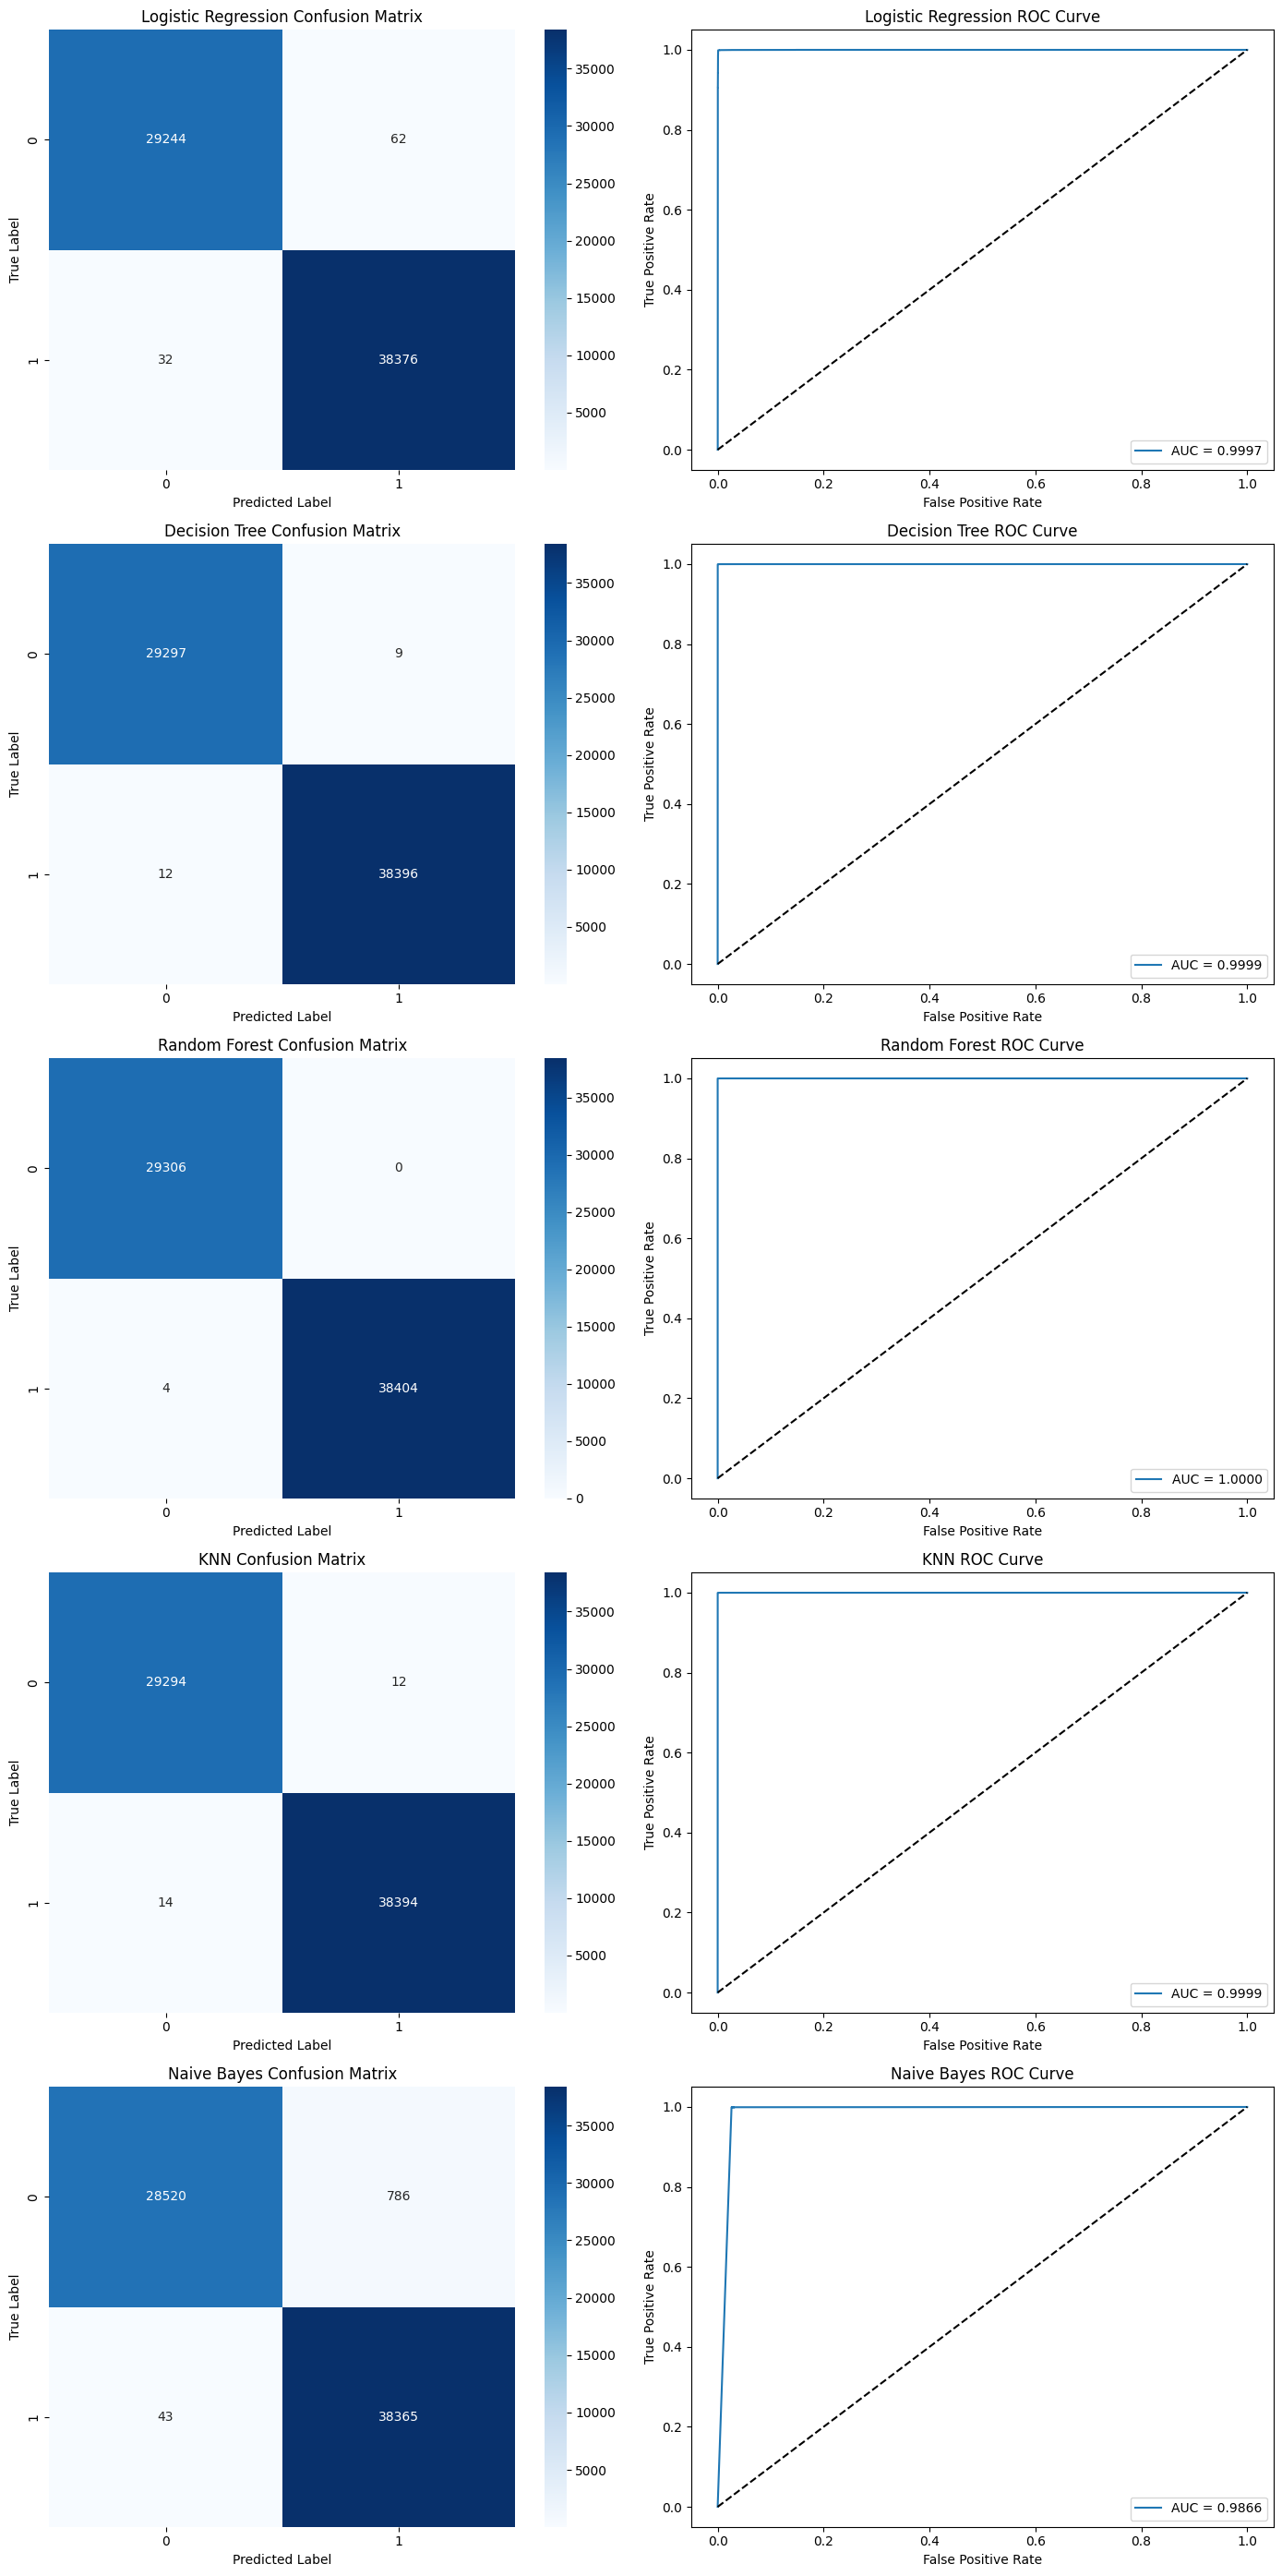

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# Initialize 5 Classical Machine Learning Algorithms
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=3, n_jobs=-1),
    "Naive Bayes": GaussianNB()
}

# Dictionary to hold metrics for later comparison
ml_results = {}

# Setup subplots for Visualizations (Confusion Matrices and ROC Curves)
fig, axes = plt.subplots(5, 2, figsize=(14, 28))
idx = 0

for name, model in models.items():
    print(f"Training and Evaluating {name}...")

    # Train the model
    model.fit(X_train_scaled, y_train)

    # Predict on testing set
    y_pred = model.predict(X_test_scaled)

    # Get probabilities/decision scores for ROC Curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)

    # Compute Evaluation Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Store metrics
    ml_results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1, "AUC": roc_auc}

    # Visualization 1: Confusion Matrix Heatmap
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx, 0])
    axes[idx, 0].set_title(f'{name} Confusion Matrix')
    axes[idx, 0].set_xlabel('Predicted Label')
    axes[idx, 0].set_ylabel('True Label')

    # Visualization 2: ROC Curve Plot
    axes[idx, 1].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    axes[idx, 1].plot([0, 1], [0, 1], 'k--')
    axes[idx, 1].set_title(f'{name} ROC Curve')
    axes[idx, 1].set_xlabel('False Positive Rate')
    axes[idx, 1].set_ylabel('True Positive Rate')
    axes[idx, 1].legend(loc='lower right')

    idx += 1

plt.tight_layout()
plt.show()


**# 5. Implementation of Artificial Neural Network (ANN)**

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,297 (28.50 KB)

 Trainable params: 7,297 (28.50 KB)

 Non-trainable params: 0 (0.00 B)

Training Artificial Neural Network...
Epoch 1/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9790 - loss: 0.0679 - precision: 0.9759 - recall: 0.9875 - val_accuracy: 0.9985 - val_loss: 0.0102 - val_precision: 0.9983 - val_recall: 0.9991
Epoch 2/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9973 - loss: 0.0129 - precision: 0.9966 - recall: 0.9986 - val_accuracy: 0.9992 - val_loss: 0.0053 - val_precision: 0.9993 - val_recall: 0.9992
Epoch 3/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9986 - loss: 0.0075 - precision: 0.9986 - recall: 0.9988 - val_accuracy: 0.9994 - val_loss: 0.0032 - val_precision: 0.9997 - val_recall: 0.9993
Epoch 4/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9988 - loss: 0.0059 - precision: 0.9990 - recall: 0.9990 - val_accuracy: 0.9993 - val_loss: 0.0026 - val_precision: 0.9994 - val_recall: 0.9993
Epoch 5/15
494/494 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9989 - loss: 0.0059 - precision: 0.9991 - recall: 0.9988

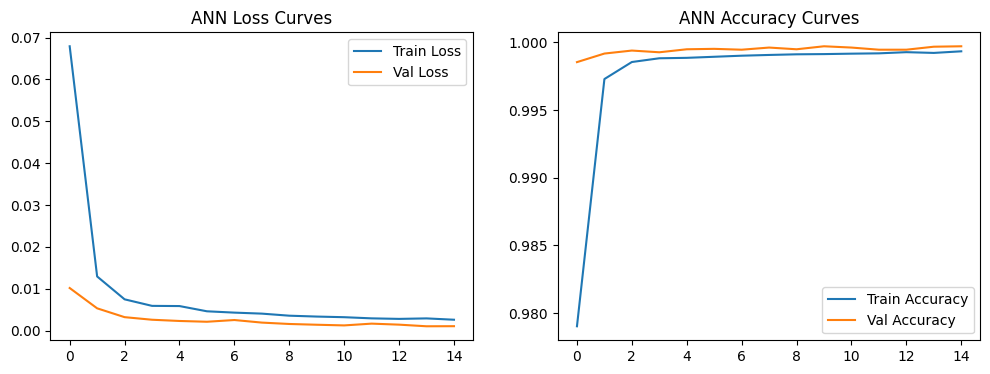

In [53]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Define ANN Architecture
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid') # Binary Output (BENIGN vs DDoS)
])

# Compile the ANN Model
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

ann_model.summary()

# Setup Early Stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train and Validate the ANN
print("Training Artificial Neural Network...")
history = ann_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate ANN performance on the test set
loss, ann_acc, ann_prec, ann_rec = ann_model.evaluate(X_test_scaled, y_test, verbose=0)
ann_f1 = 2 * (ann_prec * ann_rec) / (ann_prec + ann_rec + 1e-8)

# Compute ANN ROC/AUC
y_prob_ann = ann_model.predict(X_test_scaled).flatten()
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_prob_ann)
ann_auc = auc(fpr_ann, tpr_ann)

# Save ANN metrics to the main results dictionary
ml_results["ANN (Deep Learning)"] = {
    "Accuracy": ann_acc, "Precision": ann_prec, "Recall": ann_rec, "F1-Score": ann_f1, "AUC": ann_auc
}

# Plot ANN Training Loss & Accuracy curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('ANN Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('ANN Accuracy Curves')
plt.legend()
plt.show()

**6. Model Performance Comparison Summary**

======= FINAL PERFORMANCE METRICS MATRIX =======


,Accuracy,Precision,Recall,F1-Score,AUC
Logistic Regression,0.9986,0.9984,0.9992,0.9988,0.9997
Decision Tree,0.9997,0.9998,0.9997,0.9997,0.9999
Random Forest,0.9999,1.0000,0.9999,0.9999,1.0000
KNN,0.9996,0.9997,0.9996,0.9997,0.9999
Naive Bayes,0.9878,0.9799,0.9989,0.9893,0.9866
ANN (Deep Learning),0.9994,0.9997,0.9993,0.9995,1.0000


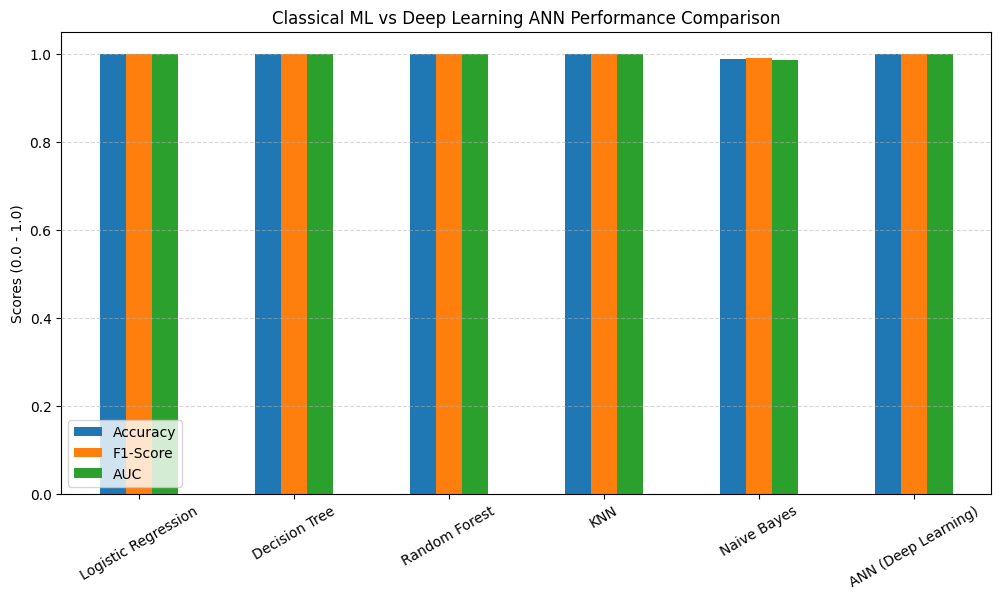

In [54]:
# Convert all results to a Pandas DataFrame for final comparison
df_comparison = pd.DataFrame(ml_results).T

print("======= FINAL PERFORMANCE METRICS MATRIX =======")
display(df_comparison.round(4))

# Visual Comparison Plot
df_comparison[['Accuracy', 'F1-Score', 'AUC']].plot(kind='bar', figsize=(12, 6))
plt.title("Classical ML vs Deep Learning ANN Performance Comparison")
plt.ylabel("Scores (0.0 - 1.0)")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.show()